In [31]:
import pandas as pd

df = pd.read_excel("../../Mandátum calc/DATA_Választási_közvélemény-kutatások_Magyarországon.xlsx", sheet_name="Adatok")




#Filter to include 7 pollsters
pollsters = ["Medián", "21 Kutató", "Republikon", "Nézőpont", "ZRI", "Publicus", "IDEA"]


df["Date"] = pd.to_datetime(df["UnixTime"], unit="s")

print(df.shape)
mask = (df["Adatgazda"].isin(pollsters)
        & df["Fókusz"].isna()
        & (df["Adatok.bázisa"] == "Biztos")
        & (df["Date"] > pd.Timestamp("2024-06-01"))) #Filter to the period after 2024, adn to decided voters

df = df[mask]

print(df.shape)
print(df["Adatgazda"].unique())
df.head()

(1727, 41)
(105, 41)
['IDEA' '21 Kutató' 'Publicus' 'ZRI' 'Nézőpont' 'Medián' 'Republikon']


,Adatok.bázisa,Kezdet,Vég,Adatgazda,Kalibrált,Fókusz,Mód,Minta,Fidesz,MSZP,...,O1GBP,Megrendelő,Forrás 1,Forrás 2,Forrás 3,Megjegyzések,UnixStart,UnixEnd,UnixTime,Date
1,Biztos,2026-02-28,2026-03-06,IDEA,1,NaN,Online,1500,37.0,0,...,NaN,A forrás nem nevezi meg.,https://24.hu/belfold/2026/03/12/tisza-fidesz-...,https://www.facebook.com/photo?fbid=1234565535...,NaN,NaN,1772236800,1772755200,1772496000,2026-03-03 00:00:00
4,Biztos,2026-03-02,2026-03-06,21 Kutató,1,NaN,Hibrid,1200,39.0,NaN,...,NaN,24.hu,https://24.hu/belfold/2026/03/11/21-kutatokozp...,https://telex.hu/belfold/2026/03/11/21-kutatok...,NaN,NaN,1772409600,1772755200,1772582400,2026-03-04 00:00:00
14,Biztos,2026-02-24,2026-02-27,Publicus,1,NaN,Telefonos,1001,35.0,NaN,...,NaN,Népszava,NaN,NaN,NaN,NaN,1771891200,1772150400,1772020800,2026-02-25 12:00:00
15,Biztos,2026-02-24,2026-02-27,Publicus,1,NaN,Telefonos,1001,39.0,NaN,...,NaN,Népszava,NaN,NaN,NaN,NaN,1771891200,1772150400,1772020800,2026-02-25 12:00:00
18,Biztos,2026-02-22,2026-02-28,ZRI,1,NaN,Hibrid,1000,38.0,NaN,...,NaN,A forrás nem nevezi meg.,https://24.hu/belfold/2026/03/03/zavecz-kutata...,https://hvg.hu/itthon/20260303_zavecz-kozvelem...,https://telex.hu/belfold/2026/03/03/zavecz-koz...,NaN,1771718400,1772236800,1771977600,2026-02-25 00:00:00


In [32]:
df_pollsters = pd.read_excel("../Poll data.xlsx", sheet_name="Pollsters") #features pollster weights


#Convert the pollster names to the weight excel
def pollster_name_map(pollster):
    if pollster == "Idea":
        return "IDEA"
    elif pollster == "21-kutato":
        return "21 Kutató"
    elif pollster == "Median":
        return "Medián"
    elif pollster == "Zavecz":
        return "ZRI"
    elif pollster == "Nezopont":
        return "Nézőpont"
    else:
        return pollster

df_pollsters["Pollster"] = df_pollsters["Pollster"].map(pollster_name_map)
df_pollsters.head()

,Pollster,Weight
0,21 Kutató,1.236224
1,IDEA,0.961413
2,Republikon,0.843453
3,Medián,1.114559
4,Nézőpont,1.016858


In [33]:
df = pd.merge(df, df_pollsters, left_on="Adatgazda", right_on="Pollster", how="left")
df.head()

,Adatok.bázisa,Kezdet,Vég,Adatgazda,Kalibrált,Fókusz,Mód,Minta,Fidesz,MSZP,...,Forrás 1,Forrás 2,Forrás 3,Megjegyzések,UnixStart,UnixEnd,UnixTime,Date,Pollster,Weight
0,Biztos,2026-02-28,2026-03-06,IDEA,1,NaN,Online,1500,37.0,0,...,https://24.hu/belfold/2026/03/12/tisza-fidesz-...,https://www.facebook.com/photo?fbid=1234565535...,NaN,NaN,1772236800,1772755200,1772496000,2026-03-03 00:00:00,IDEA,0.961413
1,Biztos,2026-03-02,2026-03-06,21 Kutató,1,NaN,Hibrid,1200,39.0,NaN,...,https://24.hu/belfold/2026/03/11/21-kutatokozp...,https://telex.hu/belfold/2026/03/11/21-kutatok...,NaN,NaN,1772409600,1772755200,1772582400,2026-03-04 00:00:00,21 Kutató,1.236224
2,Biztos,2026-02-24,2026-02-27,Publicus,1,NaN,Telefonos,1001,35.0,NaN,...,NaN,NaN,NaN,NaN,1771891200,1772150400,1772020800,2026-02-25 12:00:00,Publicus,0.942517
3,Biztos,2026-02-24,2026-02-27,Publicus,1,NaN,Telefonos,1001,39.0,NaN,...,NaN,NaN,NaN,NaN,1771891200,1772150400,1772020800,2026-02-25 12:00:00,Publicus,0.942517
4,Biztos,2026-02-22,2026-02-28,ZRI,1,NaN,Hibrid,1000,38.0,NaN,...,https://24.hu/belfold/2026/03/03/zavecz-kutata...,https://hvg.hu/itthon/20260303_zavecz-kozvelem...,https://telex.hu/belfold/2026/03/03/zavecz-koz...,NaN,1771718400,1772236800,1771977600,2026-02-25 00:00:00,ZRI,1.022770


In [34]:
t0 = df["Date"].min()
df["t"] = (df["Date"] - t0).dt.days
df = df.sort_values(by="t")
df.head()

,Adatok.bázisa,Kezdet,Vég,Adatgazda,Kalibrált,Fókusz,Mód,Minta,Fidesz,MSZP,...,Forrás 2,Forrás 3,Megjegyzések,UnixStart,UnixEnd,UnixTime,Date,Pollster,Weight,t
104,Biztos,2024-06-19,2024-06-27,IDEA,1,NaN,Online,1500,41.0,1,...,https://24.hu/belfold/2024/07/04/tisza-part-fi...,https://hvg.hu/itthon/20240704_Idea-Intezet-Ti...,NaN,1718755200,1719446400,1719100800,2024-06-23 00:00:00,IDEA,0.961413,0
103,Biztos,2024-07-04,2024-07-10,Medián,1,NaN,Telefonos,1000,43.0,NaN,...,https://hvg.hu/360/20240718_hvg-median-ep-vala...,NaN,VP:,1720051200,1720569600,1720310400,2024-07-07 00:00:00,Medián,1.114559,14
102,Biztos,2024-07-15,2024-07-17,Nézőpont,1,NaN,Telefonos,1000,47.0,NaN,...,NaN,NaN,VP: https://www.facebook.com/valasztasi.kalau...,1721001600,1721174400,1721088000,2024-07-16 00:00:00,Nézőpont,1.016858,23
101,Biztos,2024-07-24,2024-07-31,IDEA,1,NaN,Online,1500,41.0,1,...,https://www.facebook.com/photo/?fbid=819184690...,https://24.hu/belfold/2024/08/16/idea-eloszor-...,NaN,1721779200,1722384000,1722081600,2024-07-27 12:00:00,IDEA,0.961413,34
100,Biztos,2024-08-21,2024-08-31,ZRI,1,NaN,Személyes,1000,42.0,2,...,https://telex.hu/belfold/2024/09/05/magyar-pet...,NaN,"Az ""egyéb pártba"" könyveltem el 1% Szocialistá...",1724198400,1725062400,1724630400,2024-08-26 00:00:00,ZRI,1.022770,64


In [35]:
from kalman import Kalman

parties = ["Fidesz", "TISZA", "DK", "MH"]

election_results = {
    "Fidesz": 0.44307,
    "TISZA": 0.2998,
    "DK": 0.081432,
    "MH": 0.0677
}

for party in parties:

    df[party] = df[party] / 100
    sd = df[party].std() ** 2
    process_variance = 0.005 ** 2

    kalman = Kalman(initial_uncertainty=sd, process_variance=process_variance, house_error=0.02,
                    initial_state=election_results[party])

    df[party + "_kalman"] = df.apply(lambda row: kalman.update(row[party], row["t"], row["Weight"], row["Minta"]),
                                            axis=1)


df.head()



,Adatok.bázisa,Kezdet,Vég,Adatgazda,Kalibrált,Fókusz,Mód,Minta,Fidesz,MSZP,...,UnixEnd,UnixTime,Date,Pollster,Weight,t,Fidesz_kalman,TISZA_kalman,DK_kalman,MH_kalman
104,Biztos,2024-06-19,2024-06-27,IDEA,1,NaN,Online,1500,0.41,1,...,1719446400,1719100800,2024-06-23 00:00:00,IDEA,0.961413,0,0.417126,0.317554,0.080778,0.065622
103,Biztos,2024-07-04,2024-07-10,Medián,1,NaN,Telefonos,1000,0.43,NaN,...,1720569600,1720310400,2024-07-07 00:00:00,Medián,1.114559,14,0.425032,0.312740,0.080778,0.068077
102,Biztos,2024-07-15,2024-07-17,Nézőpont,1,NaN,Telefonos,1000,0.47,NaN,...,1721174400,1721088000,2024-07-16 00:00:00,Nézőpont,1.016858,23,0.445907,0.301835,0.080778,0.078659
101,Biztos,2024-07-24,2024-07-31,IDEA,1,NaN,Online,1500,0.41,1,...,1722384000,1722081600,2024-07-27 12:00:00,IDEA,0.961413,34,0.428578,0.320277,0.080243,0.069075
100,Biztos,2024-08-21,2024-08-31,ZRI,1,NaN,Személyes,1000,0.42,2,...,1725062400,1724630400,2024-08-26 00:00:00,ZRI,1.022770,64,0.423182,0.326461,0.080071,0.069714


In [36]:
import matplotlib.pyplot as plt

party_colors = {
    "Fidesz": "#fd8100",
    "TISZA": "#081c3f",
    "DK": "#007FFF",
    "MH": "#688d1b"
}

import matplotlib.font_manager as fm

bold_path = "/Users/mark/Library/Fonts/Roboto_Condensed-Bold.ttf"
regular_path = "/Users/mark/Library/Fonts/Roboto_Condensed-Black.ttf"
italic_path = '/Users/mark/Library/Fonts/Roboto_Condensed-ExtraLightItalic.ttf'
font_title = fm.FontProperties(fname=bold_path, size=26)
font_axis = fm.FontProperties(fname=bold_path, size=18)
font_legend = fm.FontProperties(fname=bold_path, size=16)
font_ticks = fm.FontProperties(fname=bold_path, size=14)
font_source = fm.FontProperties(fname=italic_path, size=12)

from matplotlib.ticker import PercentFormatter

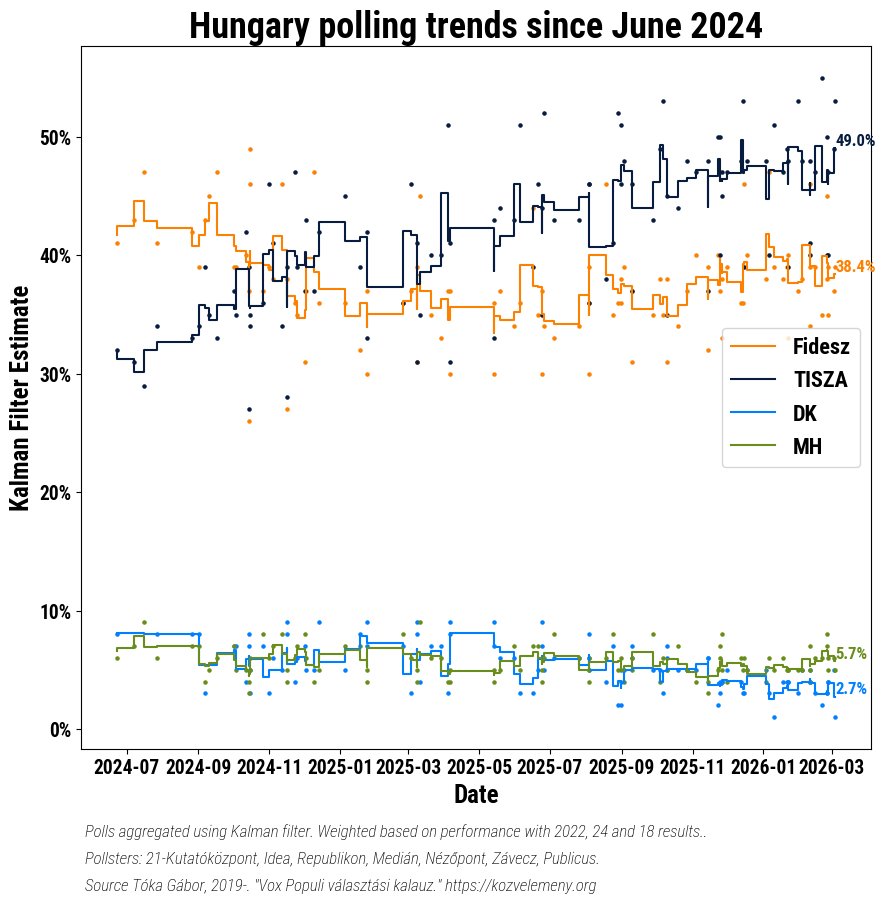

In [37]:
fig, ax = plt.subplots(figsize=(9, 9))

for party in parties:
    plt.step(df["Date"], df[party + "_kalman"], label=party, color=party_colors[party])

    last_date = df["Date"].max()
    last_value = df[party + "_kalman"].iloc[-1]

    plt.scatter(df["Date"], df[party], color=party_colors[party], s=5)

    plt.text(last_date, last_value, f"{(last_value * 100):.1f}%", color=party_colors[party],
             fontsize=12,
             fontproperties=font_ticks,
             ha="left",
             va="bottom")


plt.title("Hungary polling trends since June 2024", fontproperties=font_title)
plt.xlabel("Date", fontproperties=font_axis)
plt.ylabel("Kalman Filter Estimate", fontproperties=font_axis)



for label in ax.get_xticklabels():
    label.set_fontproperties(font_ticks)

for label in ax.get_yticklabels():
    label.set_fontproperties(font_ticks)


fig.text(0.1, 0.07, 'Polls aggregated using Kalman filter. Weighted based on performance with 2022, 24 and 18 results..', ha='left', va='center', fontproperties=font_source)
fig.text(0.1, 0.04, 'Pollsters: 21-Kutatóközpont, Idea, Republikon, Medián, Nézőpont, Závecz, Publicus. ', ha='left', va='center', fontproperties=font_source)
fig.text(0.1, 0.01, 'Source Tóka Gábor, 2019-. "Vox Populi választási kalauz." https://kozvelemeny.org', ha='left', va='center', fontproperties=font_source)



ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.legend(prop=font_legend)

plt.tight_layout(rect=(0, 0.08, 1, 1))

plt.savefig("Graphs/kalman_nyers.png", dpi=300)
plt.show()

## LOESS extra weight to last value

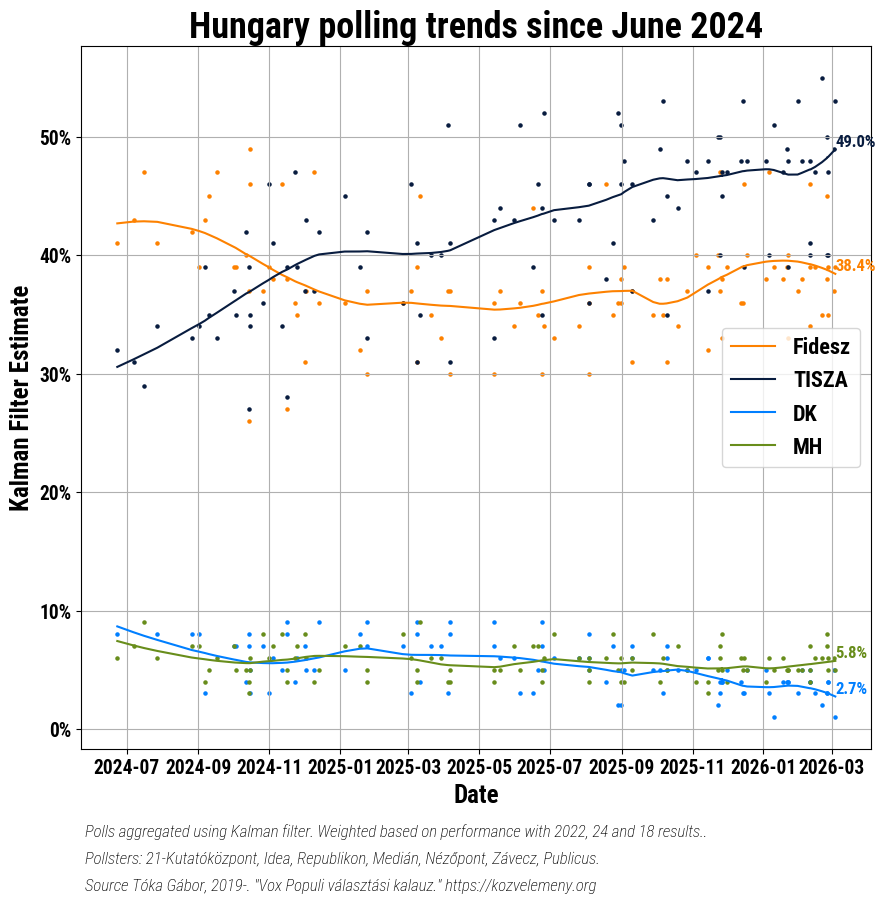

In [38]:
from skmisc.loess import loess
import numpy as np

fig, ax = plt.subplots(figsize=(9, 9))


x = df['Date'].map(pd.Timestamp.toordinal).to_numpy()
for party in parties:

    plt.scatter(df["Date"], df[party], color=party_colors[party], s=5)

    kalman_data = df[party + "_kalman"]

    weights = np.ones_like(kalman_data)
    weights[-1] = 100
    model = loess(x, kalman_data, span=0.3, weights=weights)
    model.fit()
    pred = model.predict(x, stderror=True)
    polls_smoothed = pred.values
    df[party + "_loess"] = polls_smoothed



    plt.plot(df["Date"], polls_smoothed, color=party_colors[party], label=party)

    last_date = df["Date"].max()
    last_value = polls_smoothed[-1]



    plt.text(last_date, last_value, f"{(last_value * 100):.1f}%", color=party_colors[party],
             fontsize=12,
             fontproperties=font_ticks,
             ha="left",
             va="bottom")


plt.title("Hungary polling trends since June 2024", fontproperties=font_title)
plt.xlabel("Date", fontproperties=font_axis)
plt.ylabel("Kalman Filter Estimate", fontproperties=font_axis)




for label in ax.get_xticklabels():
    label.set_fontproperties(font_ticks)

for label in ax.get_yticklabels():
    label.set_fontproperties(font_ticks)


ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.legend(prop=font_legend)

fig.text(0.1, 0.07, 'Polls aggregated using Kalman filter. Weighted based on performance with 2022, 24 and 18 results..', ha='left', va='center', fontproperties=font_source)
fig.text(0.1, 0.04, 'Pollsters: 21-Kutatóközpont, Idea, Republikon, Medián, Nézőpont, Závecz, Publicus. ', ha='left', va='center', fontproperties=font_source)
fig.text(0.1, 0.01, 'Source Tóka Gábor, 2019-. "Vox Populi választási kalauz." https://kozvelemeny.org', ha='left', va='center', fontproperties=font_source)
plt.grid(True)

plt.tight_layout(rect=(0, 0.08, 1, 1))

plt.savefig("Graphs/kalman_loess.png", dpi=300)
plt.show()

In [39]:
df.tail(10)

df.to_excel("vox_populi_kalman.xlsx", index=False)

### LOESS adding the last value separately

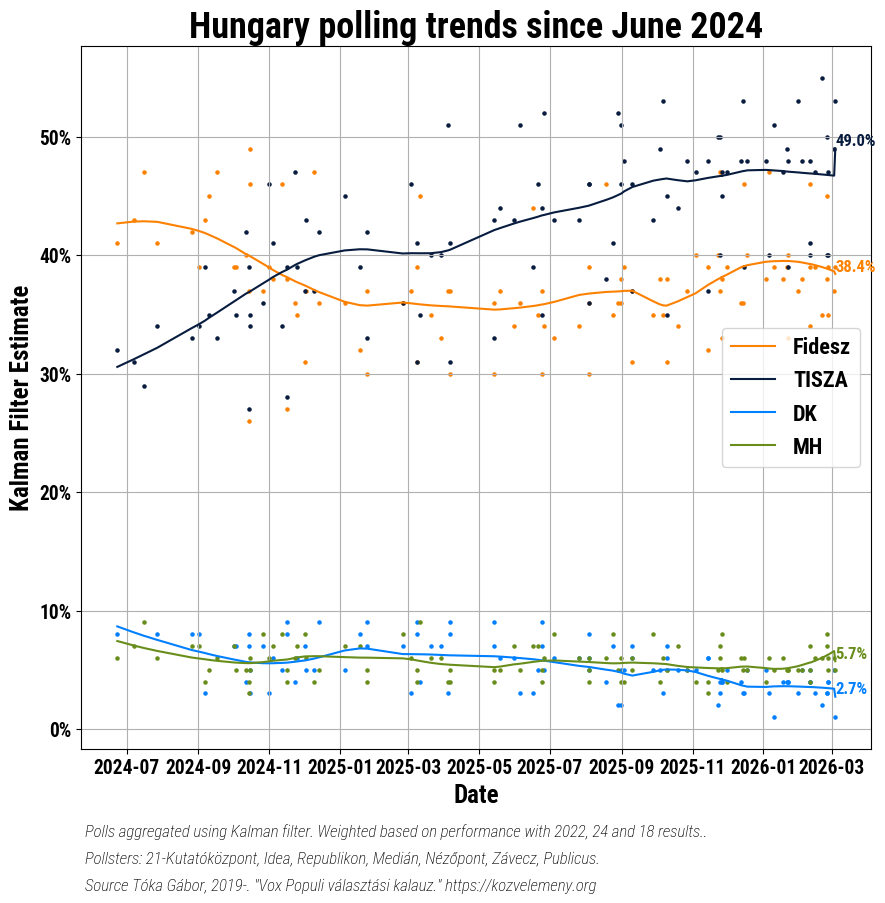

In [40]:
from skmisc.loess import loess
import numpy as np

fig, ax = plt.subplots(figsize=(9, 9))


x = df['Date'].map(pd.Timestamp.toordinal).to_numpy()
for party in parties:

    plt.scatter(df["Date"], df[party], color=party_colors[party], s=5)

    kalman_data = df[party + "_kalman"]

    model = loess(x[:-1], kalman_data[:-1], span=0.3)
    model.fit()
    pred = model.predict(x[:-1], stderror=True)
    polls_smoothed = np.append(pred.values, kalman_data.iloc[-1])



    plt.plot(df["Date"], polls_smoothed, color=party_colors[party], label=party)

    last_date = df["Date"].max()
    last_value = polls_smoothed[-1]



    plt.text(last_date, last_value, f"{(last_value * 100):.1f}%", color=party_colors[party],
             fontsize=12,
             fontproperties=font_ticks,
             ha="left",
             va="bottom")

plt.title("Hungary polling trends since June 2024", fontproperties=font_title)
plt.xlabel("Date", fontproperties=font_axis)
plt.ylabel("Kalman Filter Estimate", fontproperties=font_axis)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_ticks)

for label in ax.get_yticklabels():
    label.set_fontproperties(font_ticks)


ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.legend(prop=font_legend)

fig.text(0.1, 0.07, 'Polls aggregated using Kalman filter. Weighted based on performance with 2022, 24 and 18 results..', ha='left', va='center', fontproperties=font_source)
fig.text(0.1, 0.04, 'Pollsters: 21-Kutatóközpont, Idea, Republikon, Medián, Nézőpont, Závecz, Publicus. ', ha='left', va='center', fontproperties=font_source)
fig.text(0.1, 0.01, 'Source Tóka Gábor, 2019-. "Vox Populi választási kalauz." https://kozvelemeny.org', ha='left', va='center', fontproperties=font_source)

plt.grid(True)

plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()